<a href="https://colab.research.google.com/github/tatyanakrivonogova/machine-learning-methods/blob/master/%D0%91%D0%BB%D0%BE%D0%BA_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Линейная регрессия

## Построение линии регрессии

Суть линейной регрессии в моделировании линейной зависимости между признаками и целевой переменной. Предполагается, что зависимость описывается линейной функцией с коэффициентами, которые подбираются в процессе обучения таким образом, чтобы минимизировать значение функции потерь.

Модель линейной регрессии:
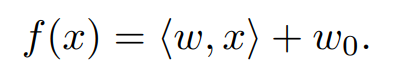

### Используемые библиотеки

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import warnings

### Датасет

In [ ]:
diabetes = load_diabetes(scaled=False)
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

print(f"Размер датасета: {df.shape}")
print("Пример данных:")
print(df.head(10))
print(df.describe().round(2))

Размер датасета: (442, 11)
Пример данных:
    age  sex   bmi     bp     s1     s2    s3    s4      s5    s6  target
0  59.0  2.0  32.1  101.0  157.0   93.2  38.0  4.00  4.8598  87.0   151.0
1  48.0  1.0  21.6   87.0  183.0  103.2  70.0  3.00  3.8918  69.0    75.0
2  72.0  2.0  30.5   93.0  156.0   93.6  41.0  4.00  4.6728  85.0   141.0
3  24.0  1.0  25.3   84.0  198.0  131.4  40.0  5.00  4.8903  89.0   206.0
4  50.0  1.0  23.0  101.0  192.0  125.4  52.0  4.00  4.2905  80.0   135.0
5  23.0  1.0  22.6   89.0  139.0   64.8  61.0  2.00  4.1897  68.0    97.0
6  36.0  2.0  22.0   90.0  160.0   99.6  50.0  3.00  3.9512  82.0   138.0
7  66.0  2.0  26.2  114.0  255.0  185.0  56.0  4.55  4.2485  92.0    63.0
8  60.0  2.0  32.1   83.0  179.0  119.4  42.0  4.00  4.4773  94.0   110.0
9  29.0  1.0  30.0   85.0  180.0   93.4  43.0  4.00  5.3845  88.0   310.0
          age     sex     bmi      bp      s1      s2      s3      s4      s5  \
count  442.00  442.00  442.00  442.00  442.00  442.00  442.00  

### Предварительная обработка датасета

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Размер тренировочной выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер тренировочной выборки: (353, 10)
Размер тестовой выборки: (89, 10)


### Тепловая карта

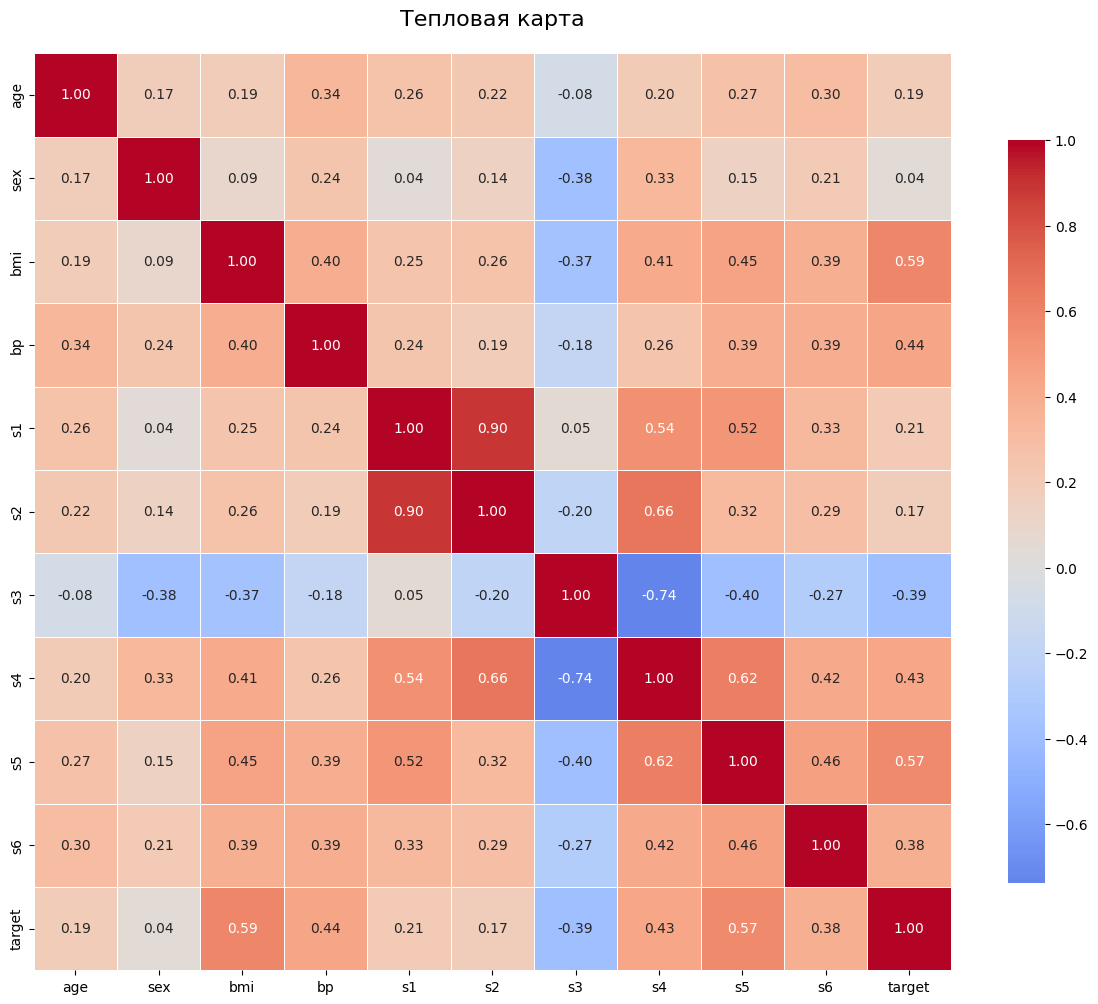

Корреляции признаков с целевой переменной:
target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64


In [ ]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title('Тепловая карта', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

print("Корреляции признаков с целевой переменной:")
target_correlations = correlation_matrix['target'].sort_values(ascending=False)
print(target_correlations)

### Обучение модели

In [ ]:
linear_model = LinearRegression()
sgd_model = SGDRegressor(
    max_iter=1000,
    tol=1e-3,
    penalty='l2',
    alpha=0.01,
    random_state=42,
    learning_rate='adaptive',
    eta0=0.01
)

linear_model.fit(X_train_scaled, y_train)
sgd_model.fit(X_train_scaled, y_train)

SGDRegressor(alpha=0.01, learning_rate='adaptive', random_state=42)

### Прогнозы модели

In [ ]:
y_pred_linear = linear_model.predict(X_test_scaled)
y_pred_sgd = sgd_model.predict(X_test_scaled)

def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"Метрики для модели {model_name}:")
    print(f"MSE:  {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE:  {mae:.2f}")
    print(f"MAPE:  {mape:.2f}")
    print(f" R²:   {r2:.4f}")

    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}

metrics_linear = evaluate_model(y_test, y_pred_linear, "Линейная регрессия (OLS)")
metrics_sgd = evaluate_model(y_test, y_pred_sgd, "SGD регрессия")

Метрики для модели Линейная регрессия (OLS):
MSE:  2900.19
RMSE: 53.85
MAE:  42.79
MAPE:  0.37
 R²:   0.4526
Метрики для модели SGD регрессия:
MSE:  2883.95
RMSE: 53.70
MAE:  42.87
MAPE:  0.37
 R²:   0.4557


### Графики выходных результатов

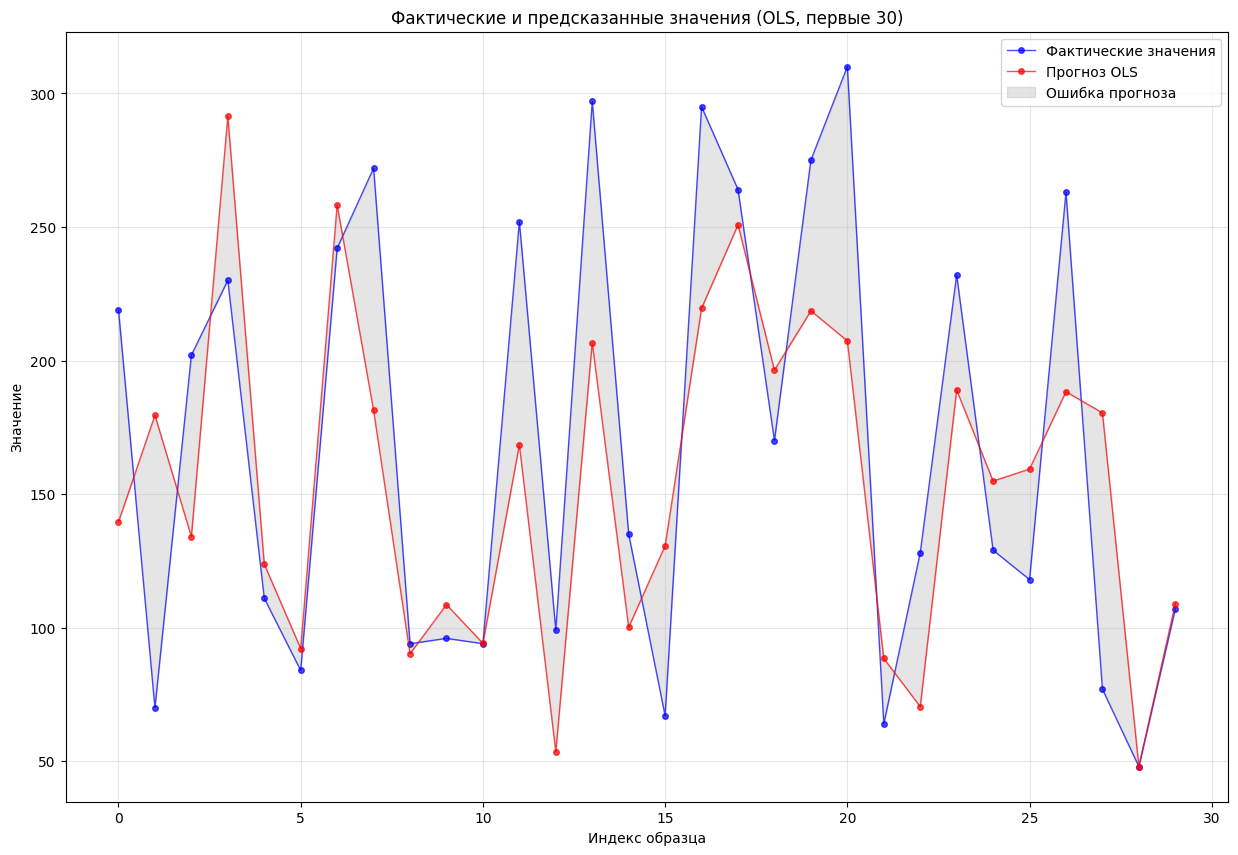

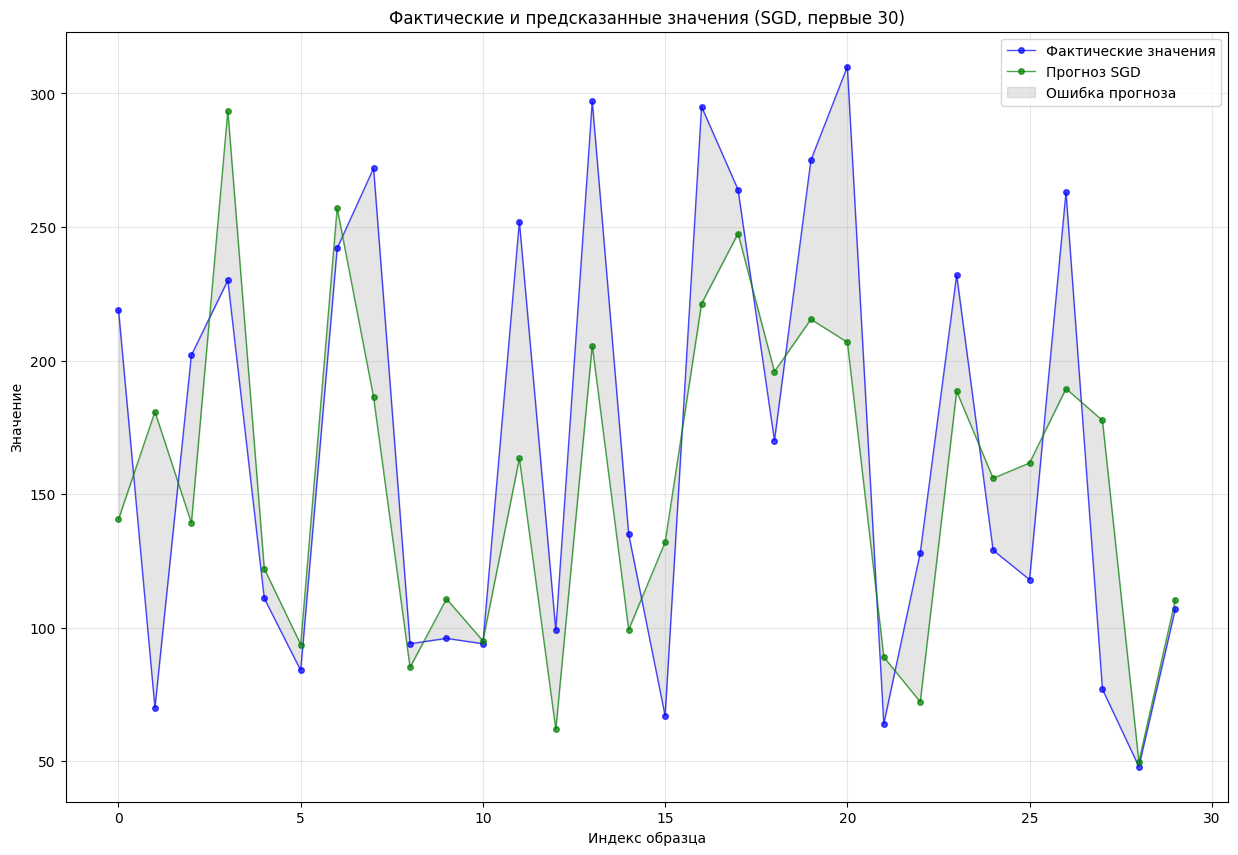

In [ ]:
fig1, ax1 = plt.subplots(figsize=(15, 10))
indices = range(len(y_test))
ax1.plot(indices[:30], y_test.values[:30], 'bo-', label='Фактические значения',
                markersize=4, linewidth=1, alpha=0.7)
ax1.plot(indices[:30], y_pred_linear[:30], 'ro-', label='Прогноз OLS',
                markersize=4, linewidth=1, alpha=0.7)
ax1.fill_between(indices[:30], y_test.values[:30], y_pred_linear[:30],
                        alpha=0.2, color='gray', label='Ошибка прогноза')
ax1.set_xlabel('Индекс образца')
ax1.set_ylabel('Значение')
ax1.set_title('Фактические и предсказанные значения (OLS, первые 30)')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

fig2, ax2 = plt.subplots(figsize=(15, 10))
ax2.plot(indices[:30], y_test.values[:30], 'bo-', label='Фактические значения',
                markersize=4, linewidth=1, alpha=0.7)
ax2.plot(indices[:30], y_pred_sgd[:30], 'go-', label='Прогноз SGD',
                markersize=4, linewidth=1, alpha=0.7)
ax2.fill_between(indices[:30], y_test.values[:30], y_pred_sgd[:30],
                        alpha=0.2, color='gray', label='Ошибка прогноза')
ax2.set_xlabel('Индекс образца')
ax2.set_ylabel('Значение')
ax2.set_title('Фактические и предсказанные значения (SGD, первые 30)')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)